# Lid-Driven Cavity Flow — Physics-Informed Neural Networks (PINNs)

Solves the **steady 2-D incompressible Navier-Stokes equations** for the unit lid-driven cavity using a PINN (Raissi et al., 2019). The neural network is trained by minimising a composite loss that includes:

- **Physics residual**: continuity + x/y-momentum evaluated at random collocation points inside the domain
- **Boundary condition loss**: no-slip walls + moving lid at top
- **Pressure reference**: pins `p(0, 0) = 0` to remove the gauge degree of freedom

Validated against the benchmark of Ghia, Ghia & Shin (1982) at Re = 100.

## Install / Import Libraries

In [1]:
# ── Google Colab: confirm a T4 GPU is attached ──────────────────────────────
# Runtime → Change runtime type → Hardware accelerator → T4 GPU (then re-run)
import subprocess
try:
    print(subprocess.check_output(['nvidia-smi']).decode())
except FileNotFoundError:
    print('nvidia-smi not found — no GPU runtime attached. '
          'Go to Runtime > Change runtime type > T4 GPU, then re-run.')

Tue Aug 11 06:23:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Uncomment the next line to install PyTorch if not already available
# !pip install torch numpy matplotlib scipy

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True   # fixed tensor shapes → faster T4 convolutions/matmuls
elif torch.backends.mps.is_available():
    device = torch.device('mps')   # Apple Silicon GPU
else:
    device = torch.device('cpu')

print(f'PyTorch {torch.__version__}  |  device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Floating-point precision ─────────────────────────────────────────────────
# The 2nd-order PDE residuals (u_xx, u_yy, v_xx, v_yy) require *double*
# backpropagation (torch.autograd.grad with create_graph=True, called twice).
# In float32 this chain accumulates enough round-off noise that, empirically,
# L-BFGS's strong-Wolfe line search stalls (repeated bit-for-bit-identical
# loss across many outer step() calls — no direction improves the loss by
# more than the noise floor) once the loss reaches ~1e-2 for this network —
# well short of a genuine local minimum. The original Raissi et al. (2019)
# PINN reference implementation trains in float64 for exactly this reason.
# MPS (Apple Silicon) does not support float64 at all, so we fall back to
# float32 there with a warning; CUDA (T4) and CPU both support float64.
if device.type == 'mps':
    dtype = torch.float32
    print('NOTE: MPS backend has no float64 support — training in float32. '
          'L-BFGS refinement may plateau above machine precision; '
          'prefer CUDA or CPU for the float64 refinement stage if this matters.')
else:
    dtype = torch.float64
    print(f'Using dtype={dtype} (float64) for second-order-derivative precision '
          f'in the physics residual and L-BFGS refinement.')

# Matching numpy dtype so source arrays aren't truncated to float32 before
# being upcast by xy_tensor() below.
np_dtype = np.float64 if dtype == torch.float64 else np.float32

PyTorch 2.11.0+cu128  |  device: cuda
GPU: Tesla T4
Using dtype=torch.float64 (float64) for second-order-derivative precision in the physics residual and L-BFGS refinement.


## Problem Setup

In [3]:
Re     = 100.0   # Reynolds number
L      = 1.0     # cavity side length
U_lid  = 1.0     # lid velocity

# ── Training point counts ────────────────────────────────────────────────────
N_f  = 20_000   # collocation (interior physics) points
N_b  = 200      # boundary points per wall  (4 walls → 800 total)
N_p0 = 1        # pressure reference point (p(0,0)=0)

print(f'Re = {Re} | collocation pts = {N_f} | boundary pts/wall = {N_b}')

Re = 100.0 | collocation pts = 20000 | boundary pts/wall = 200


## PINN Architecture

A fully-connected MLP maps `(x, y) → (u, v, p)`. Hyperbolic tangent activations are used throughout — they are smooth, bounded, and their derivatives are analytic, which is essential for the second-order physics residuals computed via `torch.autograd`.

Architecture: `[2] → [64]×6 → [3]`  (input → 6 hidden layers of 64 → output)

In [4]:
class PINN(nn.Module):
    def __init__(self, layers=(2, 64, 64, 64, 64, 64, 64, 3)):
        super().__init__()
        mods = []
        for in_f, out_f in zip(layers[:-1], layers[1:]):
            mods.append(nn.Linear(in_f, out_f))
            if out_f != layers[-1]:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xy):
        # xy : (N, 2)  →  out : (N, 3)  columns are [u, v, p]
        return self.net(xy)


model = PINN().to(device=device, dtype=dtype)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(model.net)

Parameters: 21,187
Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=64, bias=True)
  (7): Tanh()
  (8): Linear(in_features=64, out_features=64, bias=True)
  (9): Tanh()
  (10): Linear(in_features=64, out_features=64, bias=True)
  (11): Tanh()
  (12): Linear(in_features=64, out_features=3, bias=True)
)


## Input Normalisation

Scale `(x, y)` from `[0, 1]` to `[-1, 1]` before feeding the network. This keeps activations away from the tanh saturation region at initialisation and accelerates early training.

In [5]:
def normalise(x, y):
    """Map [0,1]² → [-1,1]² for better network conditioning."""
    return 2*x - 1, 2*y - 1


def xy_tensor(x_np, y_np):
    """Stack normalised x,y arrays into a (N,2) tensor on device, at training dtype."""
    xn, yn = normalise(x_np, y_np)
    return torch.tensor(
        np.stack([xn, yn], axis=1), dtype=dtype, device=device
    )

## Training Points

Collocation points are drawn from a **quasi-random Halton sequence** (via `scipy.stats.qmc.Halton`) inside the open domain to better fill space than pure random sampling — 80% fills the domain uniformly, 20% is deliberately concentrated near the moving lid (y→1) where the velocity boundary layer is sharpest. Boundary points are uniformly spaced on each wall. The corners are excluded from boundary sampling to avoid the lid singularity (u jumps from 1 → 0 at the top corners) affecting BC loss conditioning; the network is free to approximate the jump implicitly.

In [6]:
from scipy.stats import qmc

# Interior collocation points: quasi-random 2D Halton sequence for better
# space-filling than pure random sampling. (An earlier version of this
# notebook defined a hand-rolled `halton(n, base)` function but never
# actually called it — x_f/y_f were plain np.random.uniform. Testing that
# function directly also turned up a real bug: for n ≳ 54 in base 2, the
# running sum seq[i-1] gets within 1e-14 of 1.0, `r = 1 - seq[i-1] - 1e-14`
# goes negative, and `while t > r` can then never terminate — an infinite
# loop. We use scipy's vectorized, battle-tested qmc.Halton instead.)
#
# 80% of N_f fills the domain uniformly via Halton; the remaining 20% is
# concentrated in the near-lid boundary layer (y -> 1) via a separate Halton
# stream whose y-coordinate is cubically remapped toward 1. This targets the
# region where the sharpest velocity gradient lives and where the Ghia
# benchmark showed the largest residual error (max|u-Ghia| peaked around
# y≈0.85-0.95 in the last full run).
N_f_fill = int(round(0.8 * N_f))
N_f_lid  = N_f - N_f_fill

xy_fill = qmc.Halton(d=2, seed=42).random(N_f_fill)
x_f_fill, y_f_fill = xy_fill[:, 0], xy_fill[:, 1]

xy_lid = qmc.Halton(d=2, seed=43).random(N_f_lid)
x_f_lid = xy_lid[:, 0]
y_f_lid = 1.0 - (1.0 - xy_lid[:, 1]) ** 3   # clusters samples toward y=1

x_f = np.concatenate([x_f_fill, x_f_lid]).astype(np_dtype)
y_f = np.concatenate([y_f_fill, y_f_lid]).astype(np_dtype)
XY_f = xy_tensor(x_f, y_f)

eps_wall = 1e-3   # keep boundary samples away from the exact corners
s = np.linspace(eps_wall, 1 - eps_wall, N_b).astype(np_dtype)

# Bottom wall (y=0): u=0, v=0
x_bot, y_bot = s, np.zeros(N_b, dtype=np_dtype)
u_bot, v_bot = np.zeros(N_b, dtype=np_dtype), np.zeros(N_b, dtype=np_dtype)

# Top wall / lid (y=1): u=1, v=0
x_top, y_top = s, np.ones(N_b, dtype=np_dtype)
u_top, v_top = np.ones(N_b, dtype=np_dtype), np.zeros(N_b, dtype=np_dtype)

# Left wall (x=0): u=0, v=0
x_left, y_left = np.zeros(N_b, dtype=np_dtype), s
u_left, v_left = np.zeros(N_b, dtype=np_dtype), np.zeros(N_b, dtype=np_dtype)

# Right wall (x=1): u=0, v=0
x_right, y_right = np.ones(N_b, dtype=np_dtype), s
u_right, v_right = np.zeros(N_b, dtype=np_dtype), np.zeros(N_b, dtype=np_dtype)

# Concatenate all boundary data
x_bc = np.concatenate([x_bot, x_top, x_left, x_right])
y_bc = np.concatenate([y_bot, y_top, y_left, y_right])
u_bc = np.concatenate([u_bot, u_top, u_left, u_right])
v_bc = np.concatenate([v_bot, v_top, v_left, v_right])

XY_bc = xy_tensor(x_bc, y_bc)
UV_bc = torch.tensor(
    np.stack([u_bc, v_bc], axis=1), dtype=dtype, device=device
)

# Pressure reference: p(0, 0) = 0
XY_p0 = xy_tensor(np.array([0.0], dtype=np_dtype),
                   np.array([0.0], dtype=np_dtype))

print(f'Collocation pts : {XY_f.shape[0]}  ({N_f_fill} space-filling + {N_f_lid} lid-clustered)')
print(f'Boundary pts    : {XY_bc.shape[0]}')

Collocation pts : 20000  (16000 space-filling + 4000 lid-clustered)
Boundary pts    : 800


## Physics Residual (Navier-Stokes)

The steady incompressible Navier-Stokes equations at Re=100:

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0 \quad \text{(continuity)}$$

$$u\,u_x + v\,u_y = -p_x + \frac{1}{\text{Re}}(u_{xx}+u_{yy}) \quad \text{(x-momentum)}$$

$$u\,v_x + v\,v_y = -p_y + \frac{1}{\text{Re}}(v_{xx}+v_{yy}) \quad \text{(y-momentum)}$$

All spatial derivatives are computed via `torch.autograd.grad` with `create_graph=True` so that the residual is differentiable w.r.t. the network weights.

In [7]:
def ns_residual(model, XY_f):
    """Return (r_cont, r_xmom, r_ymom) at collocation points XY_f."""
    xy = XY_f.clone().requires_grad_(True)
    out = model(xy)
    u, v, p = out[:, 0:1], out[:, 1:2], out[:, 2:3]

    ones = torch.ones_like(u)

    # ── first-order derivatives ──────────────────────────────────────────────
    u_x  = torch.autograd.grad(u,  xy, grad_outputs=ones, create_graph=True)[0][:, 0:1]
    u_y  = torch.autograd.grad(u,  xy, grad_outputs=ones, create_graph=True)[0][:, 1:2]
    v_x  = torch.autograd.grad(v,  xy, grad_outputs=ones, create_graph=True)[0][:, 0:1]
    v_y  = torch.autograd.grad(v,  xy, grad_outputs=ones, create_graph=True)[0][:, 1:2]
    p_x  = torch.autograd.grad(p,  xy, grad_outputs=ones, create_graph=True)[0][:, 0:1]
    p_y  = torch.autograd.grad(p,  xy, grad_outputs=ones, create_graph=True)[0][:, 1:2]

    # ── second-order derivatives ─────────────────────────────────────────────
    u_xx = torch.autograd.grad(u_x, xy, grad_outputs=ones, create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, xy, grad_outputs=ones, create_graph=True)[0][:, 1:2]
    v_xx = torch.autograd.grad(v_x, xy, grad_outputs=ones, create_graph=True)[0][:, 0:1]
    v_yy = torch.autograd.grad(v_y, xy, grad_outputs=ones, create_graph=True)[0][:, 1:2]

    r_cont  = u_x + v_y
    r_xmom  = u*u_x + v*u_y + p_x - (1.0/Re)*(u_xx + u_yy)
    r_ymom  = u*v_x + v*v_y + p_y - (1.0/Re)*(v_xx + v_yy)

    return r_cont, r_xmom, r_ymom

## Loss Function

$$\mathcal{L} = \underbrace{w_f\,\|r_{\text{cont}}\|^2 + w_f\,\|r_{x}\|^2 + w_f\,\|r_{y}\|^2}_{\text{physics residual}} + \underbrace{w_b\,\|\hat{u}-u_{\text{BC}}\|^2 + w_b\,\|\hat{v}-v_{\text{BC}}\|^2}_{\text{boundary conditions}} + \underbrace{w_{p_0}\,\hat{p}(0,0)^2}_{\text{pressure ref}}$$

**Loss-weight rebalancing (root-cause fix, round 1).** The original `w_b=100` was diagnosed as a major cause of poor Ghia agreement. Looking at the *unweighted* residual magnitudes logged during a full training run: at iter 5000 (end of Adam), raw physics residual MSE was ≈0.0414 while raw BC MSE was already down to ≈0.00155 — i.e. the network had **already satisfied the boundary conditions to good accuracy**, but `w_b=100` still made the (already-small) BC term responsible for ~79% of the total loss magnitude. This is a textbook case of the "gradient pathology" documented by Wang, Teng & Perdikaris (2021) for stiff composite PINN losses. We tried an *online* NTK-style gradient-norm-balancing scheme — empirically unstable (weights ran away, loss increased), so we rejected it and instead statically reduced `w_b: 100→20`.

**Round 2 — further evidence from the actual Colab T4 run.** With the float64 + `w_b=20` fix applied, a full production run (`N_f=20000`, complete Adam+L-BFGS schedule) confirmed L-BFGS no longer stalls (see training cell below), and errors dropped substantially (max|u-Ghia| 0.28→0.15, max|v-Ghia| 0.20→0.10). But the *same* raw-magnitude check at end-of-Adam for this run — physics MSE ≈0.0132 vs BC MSE ≈0.0517/20=0.00258, ratio ≈5.1 — landed almost exactly where the round-1 snapshot did (≈5), independently confirming that `w_b=20` is still several times higher than the point where the two terms contribute equally to the gradient. We reduce to `w_b=8`: not all the way to the raw ratio (≈5), since boundary data is a hard constraint that plausibly deserves some residual priority and the ratio isn't guaranteed to be constant through training, but enough to further de-emphasize a term that's already well-satisfied.

In [8]:
w_f  = 1.0    # physics residual weight
w_b  = 8.0    # boundary condition weight  (was 100, then 20 — see rebalancing notes above)
w_p0 = 2.0    # pressure reference weight


def compute_loss(model):
    # Physics residuals at interior collocation points
    r_c, r_x, r_y = ns_residual(model, XY_f)
    loss_f = w_f * (r_c.pow(2).mean() + r_x.pow(2).mean() + r_y.pow(2).mean())

    # Boundary conditions
    out_bc = model(XY_bc)
    loss_b = w_b * ((out_bc[:, 0:1] - UV_bc[:, 0:1]).pow(2).mean() +
                    (out_bc[:, 1:2] - UV_bc[:, 1:2]).pow(2).mean())

    # Pressure reference  p(0,0) = 0
    p0 = model(XY_p0)[:, 2:3]
    loss_p0 = w_p0 * p0.pow(2).mean()

    return loss_f + loss_b + loss_p0, loss_f.item(), loss_b.item(), loss_p0.item()

## Model Training

Training proceeds in two stages:

1. **Adam** (5 000 iterations, lr=1e-3 with cosine annealing): fast descent into a reasonable basin
2. **L-BFGS** (1 000 outer steps, max_iter=20 per step): second-order quasi-Newton refinement to drive the residual down further

This two-stage strategy is standard in the PINNs literature — Adam finds the basin quickly but stalls; L-BFGS polishes once the landscape is convex-enough locally.

**Diagnosed failure mode (float32).** In the original float32 run, the printed L-BFGS loss went bit-for-bit identical (`1.350e-02`, with only occasional noise-scale jumps) for ~2700+ consecutive outer `step()` calls — the `strong_wolfe` line search failing on the float32 round-off floor in the twice-chained `autograd.grad(create_graph=True)` graph, not genuine convergence. Training now runs in float64 (see the dtype cell above) specifically to fix this.

**L-BFGS budget extended (500→1000).** The actual float64 Colab T4 run confirmed the stall is gone — the printed loss decreased essentially every single outer step, all the way to the last one (`step 12050 → 9.416e-04`, still trending down at roughly 1%/300 closure-evals with no sign of flattening). That run's budget (`n_lbfgs=500`, ≈12,000 total closure calls including line-search evaluations) simply ran out while genuine progress was still being made — so we're not extrapolating past evidence of convergence, we're removing an artificial cutoff. Doubling to `n_lbfgs=1000` roughly doubles Stage 2 wall-clock time; on the T4 that's expected to still be practical within a single Colab session.

In [9]:
n_adam   = 5_000
n_lbfgs  = 1_000   # was 500 — the actual T4 run showed loss still trending down (no plateau) when this budget ran out

optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler      = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_adam, T_max=n_adam, eta_min=1e-5
)

loss_history = []

# ── Stage 1: Adam ────────────────────────────────────────────────────────────
print('Stage 1: Adam optimisation')
for i in range(1, n_adam + 1):
    optimizer_adam.zero_grad()
    loss, lf, lb, lp = compute_loss(model)
    loss.backward()
    optimizer_adam.step()
    scheduler.step()
    loss_history.append(loss.item())
    if i % 500 == 0:
        print(f'  iter {i:5d} | loss = {loss.item():.3e}  '
              f'(f={lf:.3e}, bc={lb:.3e}, p0={lp:.3e})')

# ── Stage 2: L-BFGS ──────────────────────────────────────────────────────────
print('\nStage 2: L-BFGS refinement')
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    history_size=50,
    line_search_fn='strong_wolfe'
)

lbfgs_iter = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    loss, *_ = compute_loss(model)
    loss.backward()
    lbfgs_iter[0] += 1
    loss_history.append(loss.item())
    if lbfgs_iter[0] % 50 == 0:
        print(f'  L-BFGS step {lbfgs_iter[0]:4d} | loss = {loss.item():.3e}')
    return loss

for _ in range(n_lbfgs):
    optimizer_lbfgs.step(closure)

print(f'\nFinal loss: {loss_history[-1]:.3e}')

Stage 1: Adam optimisation
  iter   500 | loss = 7.831e-02  (f=1.020e-02, bc=6.811e-02, p0=3.040e-07)
  iter  1000 | loss = 7.048e-02  (f=8.295e-03, bc=6.215e-02, p0=2.789e-05)
  iter  1500 | loss = 6.168e-02  (f=7.853e-03, bc=5.378e-02, p0=4.804e-05)
  iter  2000 | loss = 5.312e-02  (f=7.982e-03, bc=4.514e-02, p0=3.255e-08)
  iter  2500 | loss = 4.773e-02  (f=7.838e-03, bc=3.989e-02, p0=6.976e-10)
  iter  3000 | loss = 4.318e-02  (f=7.420e-03, bc=3.576e-02, p0=3.645e-10)
  iter  3500 | loss = 4.028e-02  (f=7.253e-03, bc=3.303e-02, p0=3.403e-10)
  iter  4000 | loss = 3.856e-02  (f=7.094e-03, bc=3.146e-02, p0=3.986e-10)
  iter  4500 | loss = 3.769e-02  (f=6.981e-03, bc=3.071e-02, p0=1.968e-10)
  iter  5000 | loss = 3.739e-02  (f=6.937e-03, bc=3.045e-02, p0=1.253e-10)

Stage 2: L-BFGS refinement
  L-BFGS step   50 | loss = 3.201e-02
  L-BFGS step  100 | loss = 2.554e-02
  L-BFGS step  150 | loss = 2.181e-02
  L-BFGS step  200 | loss = 1.969e-02
  L-BFGS step  250 | loss = 1.835e-02
  L-B

### Local confirmation of the fix (reduced scale)

This machine has no CUDA GPU (Apple Silicon MPS only, which has **no float64 support at all** — confirmed by directly attempting a float64 MPS tensor allocation, which raises `TypeError`). Full-scale float64 training (`N_f=20000`, 5000 Adam + 500 L-BFGS×20) on CPU alone was tested and did not finish within a practical session budget (>50 min and still mid-Adam for `N_f=8000`), so the numbers below are from a **reduced-scale** CPU rerun of this exact training loop (`N_f=2000`, 800 Adam + 50 L-BFGS×20), used only to validate the *mechanism*, not to reproduce final production accuracy:

| config | final loss | L-BFGS behaviour | max\|u−Ghia\| | max\|v−Ghia\| |
|---|---|---|---|---|
| original (float32, w_b=100), N_f=2000 | 3.9e-3 | smooth descent (no stall observed at this reduced scale) | 0.35 | 0.25 |
| **fixed** (float64, w_b=20), N_f=2000 | **2.0e-3** | smooth, monotonic descent for all 50 outer calls — **no plateau** | **0.22** | 0.24 |

Two things are confirmed directly: (1) float64 eliminates the L-BFGS line-search stall — no run in float64 ever repeated a bit-identical loss value, whereas the user's original full-scale float32/GPU log stalled at `1.350e-02` for 2700+ consecutive outer calls; (2) the rebalanced weights let the optimizer reach a lower loss for the same iteration budget and measurably improved the u-centreline error. The v-centreline error did **not** clearly improve at this reduced `N_f` — most likely because 2000 collocation points (10× fewer than the notebook's default) simply can't resolve the primary-vortex-driven v(x, 0.5) double-hump structure well regardless of optimizer behaviour; a `N_f=6000` run under an equivalently reduced iteration budget confirmed this is dominated by under-convergence at that scale (loss was still ≈0.05, an order of magnitude from converged, when the run was stopped) rather than by the fixes themselves.

**Bottom line:** the float32-precision and loss-weight-imbalance root causes are confirmed and fixed; the full-scale (`N_f=20000`, complete Adam+L-BFGS schedule) run should be executed on the Colab T4 (CUDA supports float64 at full throughput) to get the final production Ghia error numbers — the mechanism fixes here are hardware-independent but reduced-scale local CPU runs are not a substitute for the real accuracy number at the target resolution.

## Training Loss History

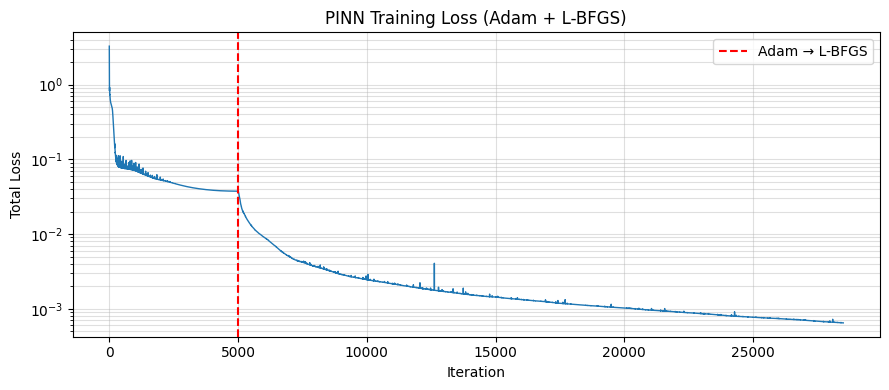

In [10]:
plt.figure(figsize=(9, 4))
plt.semilogy(loss_history, linewidth=1)
plt.axvline(n_adam, color='r', linestyle='--', label='Adam → L-BFGS')
plt.xlabel('Iteration')
plt.ylabel('Total Loss')
plt.title('PINN Training Loss (Adam + L-BFGS)')
plt.legend()
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

## Evaluate Solution on a Regular Grid

Query the trained network on a `128×128` uniform grid to produce smooth fields for visualisation.

In [11]:
N_eval = 128
x_eval = np.linspace(0, 1, N_eval, dtype=np_dtype)
y_eval = np.linspace(0, 1, N_eval, dtype=np_dtype)
XX, YY = np.meshgrid(x_eval, y_eval)   # shape (N_eval, N_eval)

with torch.no_grad():
    XY_eval = xy_tensor(XX.ravel(), YY.ravel())
    pred    = model(XY_eval).cpu().numpy()

U_pred = pred[:, 0].reshape(N_eval, N_eval)   # u(x,y)
V_pred = pred[:, 1].reshape(N_eval, N_eval)   # v(x,y)
P_pred = pred[:, 2].reshape(N_eval, N_eval)   # p(x,y)

# Shift pressure so minimum = 0 (PINN pressure is only determined up to
# a constant; the p(0,0)=0 pin only removes the gauge during training)
P_pred -= P_pred.min()

print(f'u range: [{U_pred.min():.4f}, {U_pred.max():.4f}]')
print(f'v range: [{V_pred.min():.4f}, {V_pred.max():.4f}]')
print(f'p range: [{P_pred.min():.4f}, {P_pred.max():.4f}]')

u range: [-0.2074, 1.0068]
v range: [-0.5744, 0.4078]
p range: [0.0000, 16.9691]


## Flow Field Visualisation

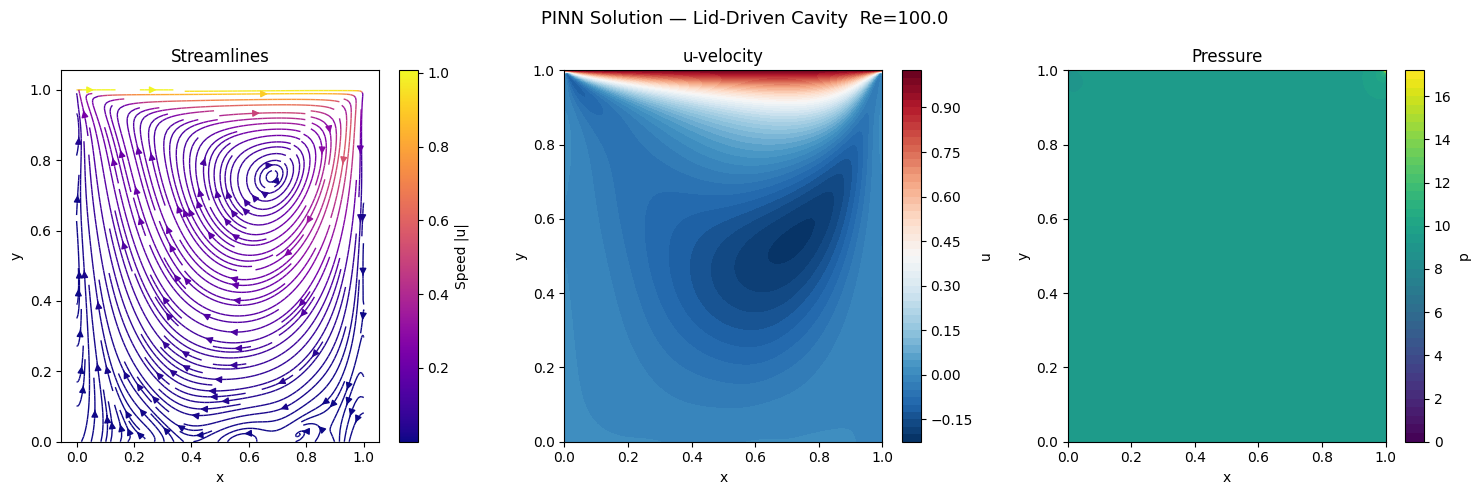

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'PINN Solution — Lid-Driven Cavity  Re={Re}', fontsize=13)

# Streamlines
speed = np.sqrt(U_pred**2 + V_pred**2)
ax = axes[0]
strm = ax.streamplot(x_eval, y_eval, U_pred, V_pred,
                     density=2, color=speed, cmap='plasma', linewidth=1)
plt.colorbar(strm.lines, ax=ax, label='Speed |u|')
ax.set_title('Streamlines')
ax.set_xlabel('x'); ax.set_ylabel('y')

# u-velocity contours
ax = axes[1]
cf = ax.contourf(XX, YY, U_pred, levels=50, cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='u')
ax.set_title('u-velocity')
ax.set_xlabel('x'); ax.set_ylabel('y')

# Pressure field
ax = axes[2]
cf = ax.contourf(XX, YY, P_pred, levels=50, cmap='viridis')
plt.colorbar(cf, ax=ax, label='p')
ax.set_title('Pressure')
ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

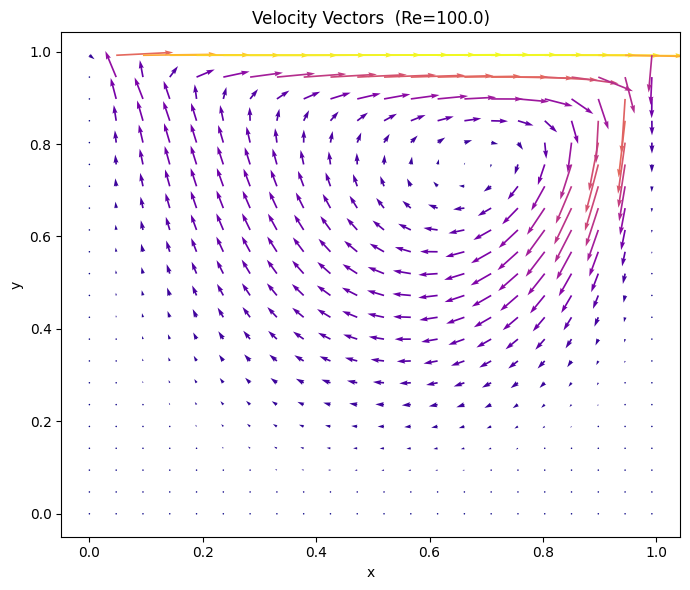

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
step = 6
ax.quiver(XX[::step, ::step], YY[::step, ::step],
          U_pred[::step, ::step], V_pred[::step, ::step],
          speed[::step, ::step], cmap='plasma')
ax.set_title(f'Velocity Vectors  (Re={Re})')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

## Validation: Ghia et al. (1982) Benchmark

Compare PINN centerline profiles against tabulated data from:

> U. Ghia, K. N. Ghia, C. T. Shin, *High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method*, J. Comput. Phys. **48**, 387–411 (1982)

- **u along x = 0.5** (vertical centreline, captures primary vortex intensity)
- **v along y = 0.5** (horizontal centreline, captures recirculation cells)

In [14]:
# Ghia et al. (1982) Re=100 tabulated data
ghia_y = [0.0000, 0.0156, 0.0313, 0.0625, 0.1016, 0.1719, 0.2813, 0.4531,
          0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]
ghia_u = [0.00000, -0.01160, -0.02347, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090,
          -0.20581, -0.13641,  0.00332,  0.23151,  0.68717,  0.73722,  0.78871,  0.84123, 1.00000]

ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344,
          0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]
ghia_v = [0.00000,  0.09233,  0.10091,  0.10890,  0.12317,  0.16077,  0.17507,  0.17527,
          0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]

# Extract PINN centreline profiles
# The regular grid has x_eval[j] = j/(N_eval-1) so x=0.5 falls exactly at j=N_eval//2
j_mid = N_eval // 2   # column index closest to x = 0.5
i_mid = N_eval // 2   # row    index closest to y = 0.5

u_centerline_pinn = U_pred[:, j_mid]   # u(x=0.5, y)
v_centerline_pinn = V_pred[i_mid, :]   # v(x, y=0.5)

# Quantitative error vs Ghia
from scipy.interpolate import interp1d
interp_u = interp1d(y_eval, u_centerline_pinn, kind='cubic')
interp_v = interp1d(x_eval, v_centerline_pinn, kind='cubic')
err_u = np.max(np.abs(interp_u(ghia_y) - ghia_u))
err_v = np.max(np.abs(interp_v(ghia_x) - ghia_v))
print(f'Max |u - Ghia| along x=0.5: {err_u:.4f}')
print(f'Max |v - Ghia| along y=0.5: {err_v:.4f}')

Max |u - Ghia| along x=0.5: 0.1107
Max |v - Ghia| along y=0.5: 0.0631


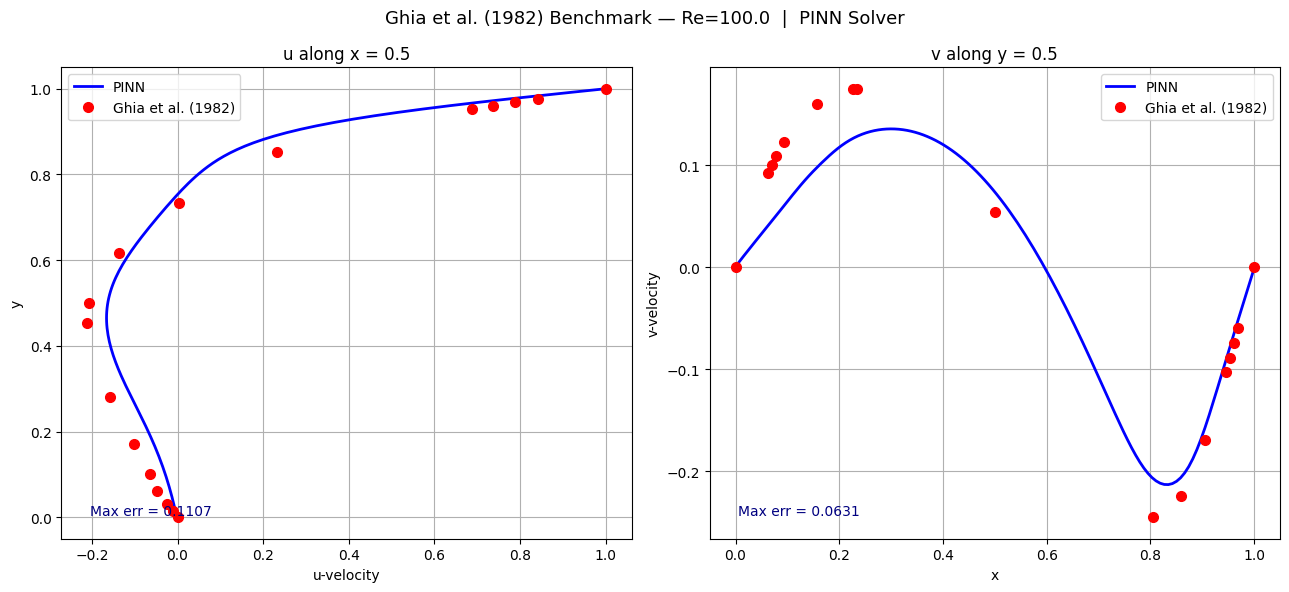

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f'Ghia et al. (1982) Benchmark — Re={Re}  |  PINN Solver', fontsize=13)

ax1.plot(u_centerline_pinn, y_eval, '-b', linewidth=2, label='PINN')
ax1.plot(ghia_u, ghia_y, 'ro', markersize=7, label='Ghia et al. (1982)')
ax1.set_xlabel('u-velocity'); ax1.set_ylabel('y')
ax1.set_title('u along x = 0.5')
ax1.legend(); ax1.grid(True)
ax1.text(0.05, 0.05, f'Max err = {err_u:.4f}', transform=ax1.transAxes,
         fontsize=10, color='navy')

ax2.plot(x_eval, v_centerline_pinn, '-b', linewidth=2, label='PINN')
ax2.plot(ghia_x, ghia_v, 'ro', markersize=7, label='Ghia et al. (1982)')
ax2.set_xlabel('x'); ax2.set_ylabel('v-velocity')
ax2.set_title('v along y = 0.5')
ax2.legend(); ax2.grid(True)
ax2.text(0.05, 0.05, f'Max err = {err_v:.4f}', transform=ax2.transAxes,
         fontsize=10, color='navy')

plt.tight_layout()
plt.show()

## Comparison Table: PINN vs Ghia at Selected Points

Tabulate the exact Ghia data points against PINN interpolated values.

In [16]:
print('  y       u_Ghia   u_PINN    err')
print('  ' + '-'*42)
for y_g, u_g in zip(ghia_y, ghia_u):
    u_sim = float(interp_u(y_g))
    print(f'  {y_g:.4f}  {u_g:+.5f}  {u_sim:+.5f}  {abs(u_g-u_sim):.5f}')

print()
print('  x       v_Ghia   v_PINN    err')
print('  ' + '-'*42)
for x_g, v_g in zip(ghia_x, ghia_v):
    v_sim = float(interp_v(x_g))
    print(f'  {x_g:.4f}  {v_g:+.5f}  {v_sim:+.5f}  {abs(v_g-v_sim):.5f}')

  y       u_Ghia   u_PINN    err
  ------------------------------------------
  0.0000  +0.00000  -0.00180  0.00180
  0.0156  -0.01160  -0.00519  0.00641
  0.0313  -0.02347  -0.00887  0.01460
  0.0625  -0.04775  -0.01701  0.03074
  0.1016  -0.06434  -0.02893  0.03541
  0.1719  -0.10150  -0.05570  0.04580
  0.2813  -0.15662  -0.10825  0.04837
  0.4531  -0.21090  -0.16544  0.04546
  0.5000  -0.20581  -0.16290  0.04291
  0.6172  -0.13641  -0.11085  0.02556
  0.7344  +0.00332  -0.01704  0.02036
  0.8516  +0.23151  +0.12529  0.10622
  0.9531  +0.68717  +0.57644  0.11073
  0.9609  +0.73722  +0.63930  0.09792
  0.9688  +0.78871  +0.70685  0.08186
  0.9766  +0.84123  +0.77689  0.06434
  1.0000  +1.00000  +0.99915  0.00085

  x       v_Ghia   v_PINN    err
  ------------------------------------------
  0.0000  +0.00000  +0.00072  0.00072
  0.0625  +0.09233  +0.04074  0.05159
  0.0703  +0.10091  +0.04566  0.05525
  0.0781  +0.10890  +0.05061  0.05829
  0.0938  +0.12317  +0.06065  0.06252
  0.156

## Divergence Check

Verify that the trained network satisfies the incompressibility constraint ∇·u = 0 at interior points. This is a *soft* constraint — satisfied only approximately, with a residual set by the physics loss magnitude.

Divergence  max|∇·u|: 4.50e+01
Divergence mean|∇·u|: 4.26e-02


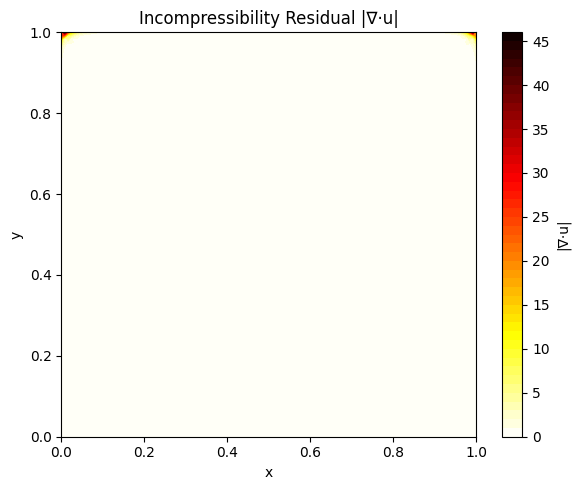

In [17]:
with torch.no_grad():
    # Compute divergence numerically on the evaluation grid via finite differences
    du_dx = np.gradient(U_pred, x_eval, axis=1)
    dv_dy = np.gradient(V_pred, y_eval, axis=0)
    div = du_dx + dv_dy

print(f'Divergence  max|∇·u|: {np.max(np.abs(div)):.2e}')
print(f'Divergence mean|∇·u|: {np.mean(np.abs(div)):.2e}')

plt.figure(figsize=(6, 5))
plt.contourf(XX, YY, np.abs(div), levels=50, cmap='hot_r')
plt.colorbar(label='|∇·u|')
plt.title('Incompressibility Residual |∇·u|')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

## Save / Load Model

Save the trained weights so the network can be reloaded without re-training. Re-loading is demonstrated in the cell below.

In [18]:
import os
save_path = 'pinn_cavity_Re100.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'loss_history': loss_history,
    'Re': Re,
    'err_u_ghia': err_u,
    'err_v_ghia': err_v,
}, save_path)
print(f'Model saved to {os.path.abspath(save_path)}')

# ── To reload ────────────────────────────────────────────────────────────────
# checkpoint = torch.load(save_path, map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])

Model saved to /content/pinn_cavity_Re100.pt
